In [1]:
import pandas as pd

df = pd.read_csv("abtest_raw.csv")
df.head(20)


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0.0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0.0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0.0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0.0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1.0
5,936923,2017-01-10 15:20:49.083499,control,old_page,0.0
6,679687,2017-01-19 03:26:46.940749,treatment,new_page,1.0
7,719014,2017-01-17 01:48:29.539573,control,old_page,0.0
8,817355,2017-01-04 17:58:08.979471,treatment,new_page,1.0
9,839785,2017-01-15 18:11:06.610965,treatment,new_page,1.0


In [2]:
df.columns

Index(['user_id', 'timestamp', 'group', 'landing_page', 'converted'], dtype='object')

In [3]:
df.duplicated('user_id').sum()

np.int64(415)

In [4]:
df[df.duplicated('user_id', keep=False)]



,user_id,timestamp,group,landing_page,converted
226,773693,2017-01-23 18:05:45.167335,control,old_page,1.0
246,704650,2017-01-04 19:10:52.655062,treatment,new_page,0.0
357,856078,2017-01-12 12:29:30.354835,treatment,old_page,0.0
478,867227,2017-01-06 07:27:11.191816,control,old_page,1.0
654,823319,2017-01-20 09:02:25.852683,treatment,new_page,0.0
...,...,...,...,...,...
96674,772250,2017-01-19 23:51:06.381719,treatment,old_page,0.0
96785,943323,2017-01-21 04:18:10.925456,control,new_page,0.0
96804,764160,2017-01-15 17:52:49.568242,control,new_page,1.0
96861,799231,2017-01-12 17:38:00.478541,control,old_page,0.0


In [25]:
## Remove the duplicate keeping the first visit
df = df.drop_duplicates('user_id', keep='first')


In [6]:
#converting the 'timestamp' column datatype from string to datetime object
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 96672 entries, 0 to 97086
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       96672 non-null  int64         
 1   timestamp     96672 non-null  datetime64[ns]
 2   group         96671 non-null  object        
 3   landing_page  96671 non-null  object        
 4   converted     96671 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 4.4+ MB


In [7]:
#check whether the control and treatment have roughly the same sample sizes
## result confirms that they do.

df['group'].value_counts(normalize=True)

,proportion
group,
treatment,0.500905
control,0.499095


In [8]:
## Checking for landing page mismatches — verifying how many control users saw the old vs. new page, and how many treatment users saw the old vs. new page. This ensures that each user was shown the correct page for their assigned experiment group

df.groupby(['group', 'landing_page']).size()

group      landing_page
control    new_page          558
           old_page        47690
treatment  new_page        47855
           old_page          568
dtype: int64

In [9]:
# Filter out incorrect rows. We only want:

## control → old_page

## treatment → new_page

df = df[
    ((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))
]


In [10]:
df.groupby(['group', 'landing_page']).size()


,,0
group,landing_page,
control,old_page,47690
treatment,new_page,47855


In [11]:
#Compute conversion rates by group
df.groupby('group')['converted'].mean()

,converted
group,
control,0.120445
treatment,0.118984


In [12]:
# Statistical test ran and results are clearly displayed for z-statistic and p-value

from statsmodels.stats.proportion import proportions_ztest

conversions = df.groupby('group')['converted'].sum()
samples = df.groupby('group')['converted'].count()

z_stat, p_val = proportions_ztest(conversions, samples)
z_stat, p_val

print(f"z-statistic is: {z_stat}")
print(f"p-value is: {p_val}")



z-statistic is: 0.6951434316083999
p-value is: 0.48696541893698


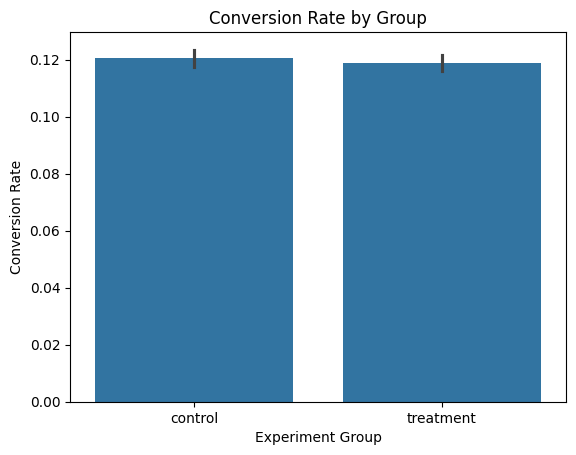

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df, x='group', y='converted')
plt.title("Conversion Rate by Group")
plt.ylabel("Conversion Rate")
plt.xlabel("Experiment Group")
plt.show()


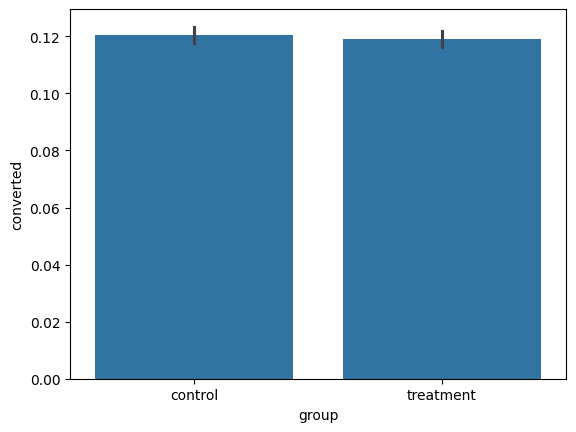

In [14]:
sns.barplot(data=df, x='group', y='converted', errorbar=('ci', 95));


In [15]:
conversion_rates = df.groupby('group')['converted'].mean()
conversion_rates


,converted
group,
control,0.120445
treatment,0.118984


In [16]:
diff = conversion_rates['treatment'] - conversion_rates['control']
diff
print(f"Conversion rate difference is: {diff}")


Conversion rate difference is: -0.0014601055001655233


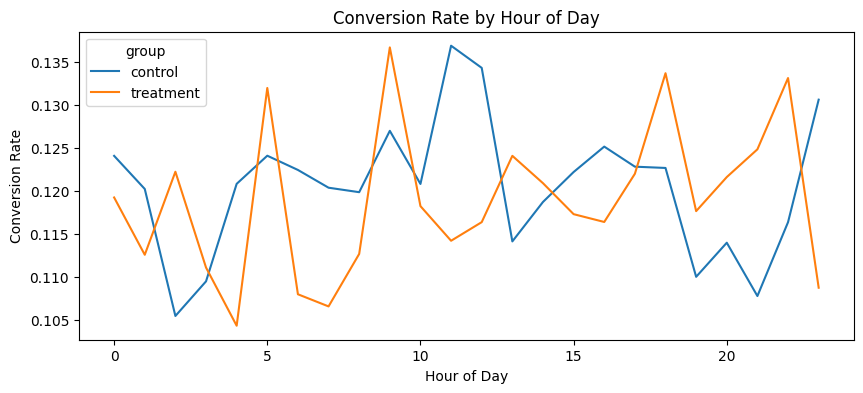

In [17]:
## Calculate hourly conversion rate
df['hour'] = df['timestamp'].dt.hour

df.groupby(['hour', 'group'])['converted'].mean().unstack().plot(figsize=(10,4))
plt.title("Conversion Rate by Hour of Day")
plt.ylabel("Conversion Rate")
plt.xlabel("Hour of Day")
plt.show()


In [18]:
from statsmodels.stats.proportion import proportions_ztest

conversions = df.groupby('group')['converted'].sum()
samples = df.groupby('group')['converted'].count()

z_stat, p_val = proportions_ztest(conversions, samples)

print(f"z-statistic is: {z_stat}")
print(f"p-value is: {p_val}")


z-statistic is: 0.6951434316083999
p-value is: 0.48696541893698


In [19]:
import statsmodels.api as sm

control = df[df['group']=='control']['converted']
treatment = df[df['group']=='treatment']['converted']

cm = sm.stats.CompareMeans(sm.stats.DescrStatsW(treatment),
                           sm.stats.DescrStatsW(control))

ci_low, ci_high = cm.tconfint_diff()

print("95% CI for difference (treatment - control):")
print(ci_low, ci_high)


95% CI for difference (treatment - control):
-0.005576972658201629 0.0026567616578705823


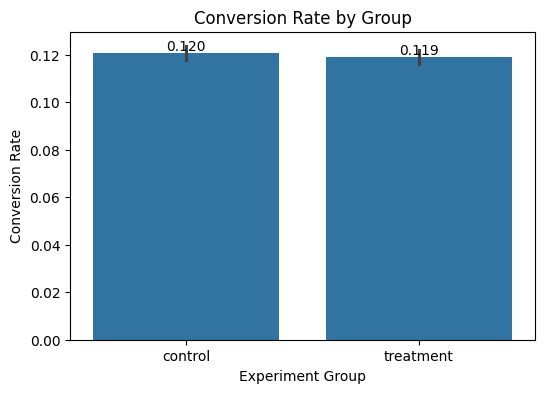

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
ax = sns.barplot(data=df, x='group', y='converted', errorbar=('ci', 95))
plt.title("Conversion Rate by Group")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate")
ax.bar_label(ax.containers[0], fmt="%.3f")
plt.show()


In [26]:
# Conversion rates
cr_control = 0.1204
cr_treatment = 0.1188

# -----------------------------
# 1. Absolute Lift
# -----------------------------
absolute_lift = cr_treatment - cr_control

# -----------------------------
# 2. Relative Lift (Standard)
# Denominator = control CR
# -----------------------------
relative_lift_standard = (cr_treatment - cr_control) / cr_control

# -----------------------------
# 3. Relative Lift (Pooled)
# Denominator = pooled CR
# -----------------------------
# Example group sizes (replace with your actual n_control, n_treatment)
n_control = 147239
n_treatment = 147240

cr_pooled = (cr_control * n_control + cr_treatment * n_treatment) / (n_control + n_treatment)
relative_lift_pooled = (cr_treatment - cr_control) / cr_pooled

# -----------------------------
# Print results
# -----------------------------
print("Absolute Lift:", absolute_lift)
print("Relative Lift (Standard):", relative_lift_standard)
print("Relative Lift (Pooled):", relative_lift_pooled)


Absolute Lift: -0.0015999999999999903
Relative Lift (Standard): -0.013289036544850419
Relative Lift (Pooled): -0.013377926725278422


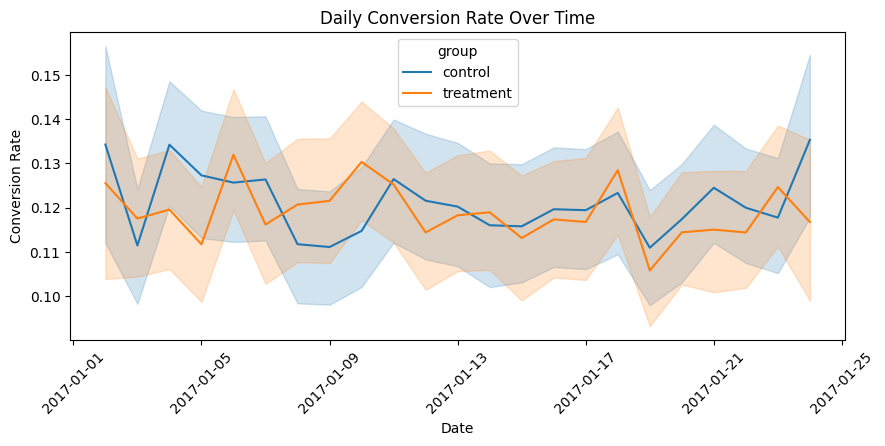

In [22]:
df['date'] = df['timestamp'].dt.date

plt.figure(figsize=(10,4))
sns.lineplot(data=df, x='date', y='converted', hue='group')
plt.title("Daily Conversion Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)
plt.show()


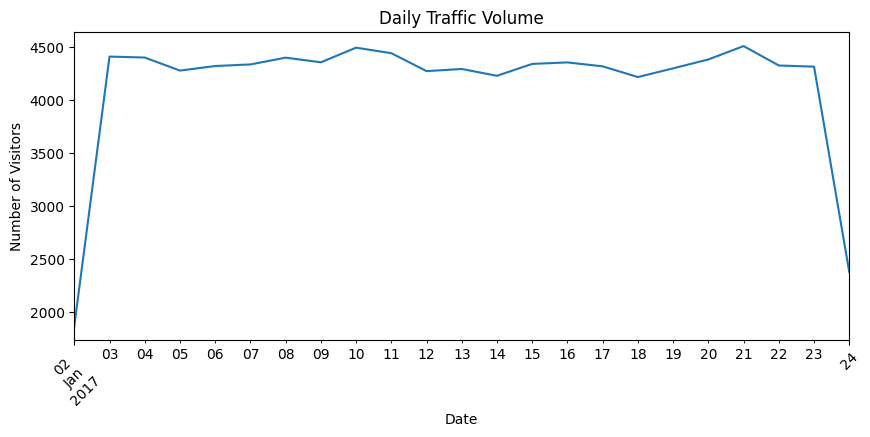

In [23]:
plt.figure(figsize=(10,4))
df.set_index('timestamp').resample('D').size().plot()
plt.title("Daily Traffic Volume")
plt.xlabel("Date")
plt.ylabel("Number of Visitors")
plt.xticks(rotation=45)
plt.show()


In [24]:
summary = df.groupby('group')['converted'].agg(
    conversion_rate='mean',
    conversions='sum',
    sample_size='count'
)
summary


,conversion_rate,conversions,sample_size
group,,,
control,0.120445,5744.0,47690
treatment,0.118984,5694.0,47855
